# Sales Effectiveness

# Problem Statement

FicZon business is majorly dependent on the sales force effectiveness.

As the market is maturing and more new competitorsentering the market, FicZon is experiencing the dip in sales.

Effective sales is dependent on lead quality and as of now, this isbased on manual categorization and highly depended on sales staff.

Though there is a quality process, which continuously updates thelead categorization, it’s value is in for post analysis, rather than
conversation.

PROJECT GOAL:
1. Data exploration insights – Sales effectiveness.
2. ML model to predict the Lead Category (High Potential , Low Potential).

# Importing libraries 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Loading Dataset

In [2]:
df=pd.read_csv('sales_datas.csv', sep=';')

In [3]:
df

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
...,...,...,...,...,...,...,...,...,...
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


# Basic Checks

In [4]:
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7422 non-null   object 
 1   Product_ID     7364 non-null   float64
 2   Source         7405 non-null   object 
 3   Mobile         5612 non-null   object 
 4   EMAIL          7422 non-null   object 
 5   Sales_Agent    7399 non-null   object 
 6   Location       7364 non-null   object 
 7   Delivery_Mode  7422 non-null   object 
 8   Status         7422 non-null   object 
dtypes: float64(1), object(8)
memory usage: 522.0+ KB


In [6]:
df.describe()

,Product_ID
count,7364.000000
mean,15.947311
std,6.072937
min,0.000000
25%,12.000000
50%,18.000000
75%,19.000000
max,28.000000


In [7]:
df.shape

(7422, 9)

In [8]:
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25.0,Website,NaN,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


# Domain Analysis

Lead Quality Signals:

1.A missing Mobile number (24% missing) is likely a strong indicator of a low-quality lead — incomplete leads tend to convert less.
2.Source reflects marketing channel ROI — some channels likely generate higher-quality leads.
3.Product_ID and Delivery_Mode indicate which product segment a lead belongs to — SaaS vs on-prem leads may behave differently.

Sales Effectiveness Signals:

1.Sales_Agent allows agent-level performance analysis — some agents may close higher-potential leads.
2.Location enables regional segmentation — useful for territory management.
3.Created allows temporal analysis — lead quality may vary by day/week/quarter.

# EDA

In [9]:
df.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

# Univariante

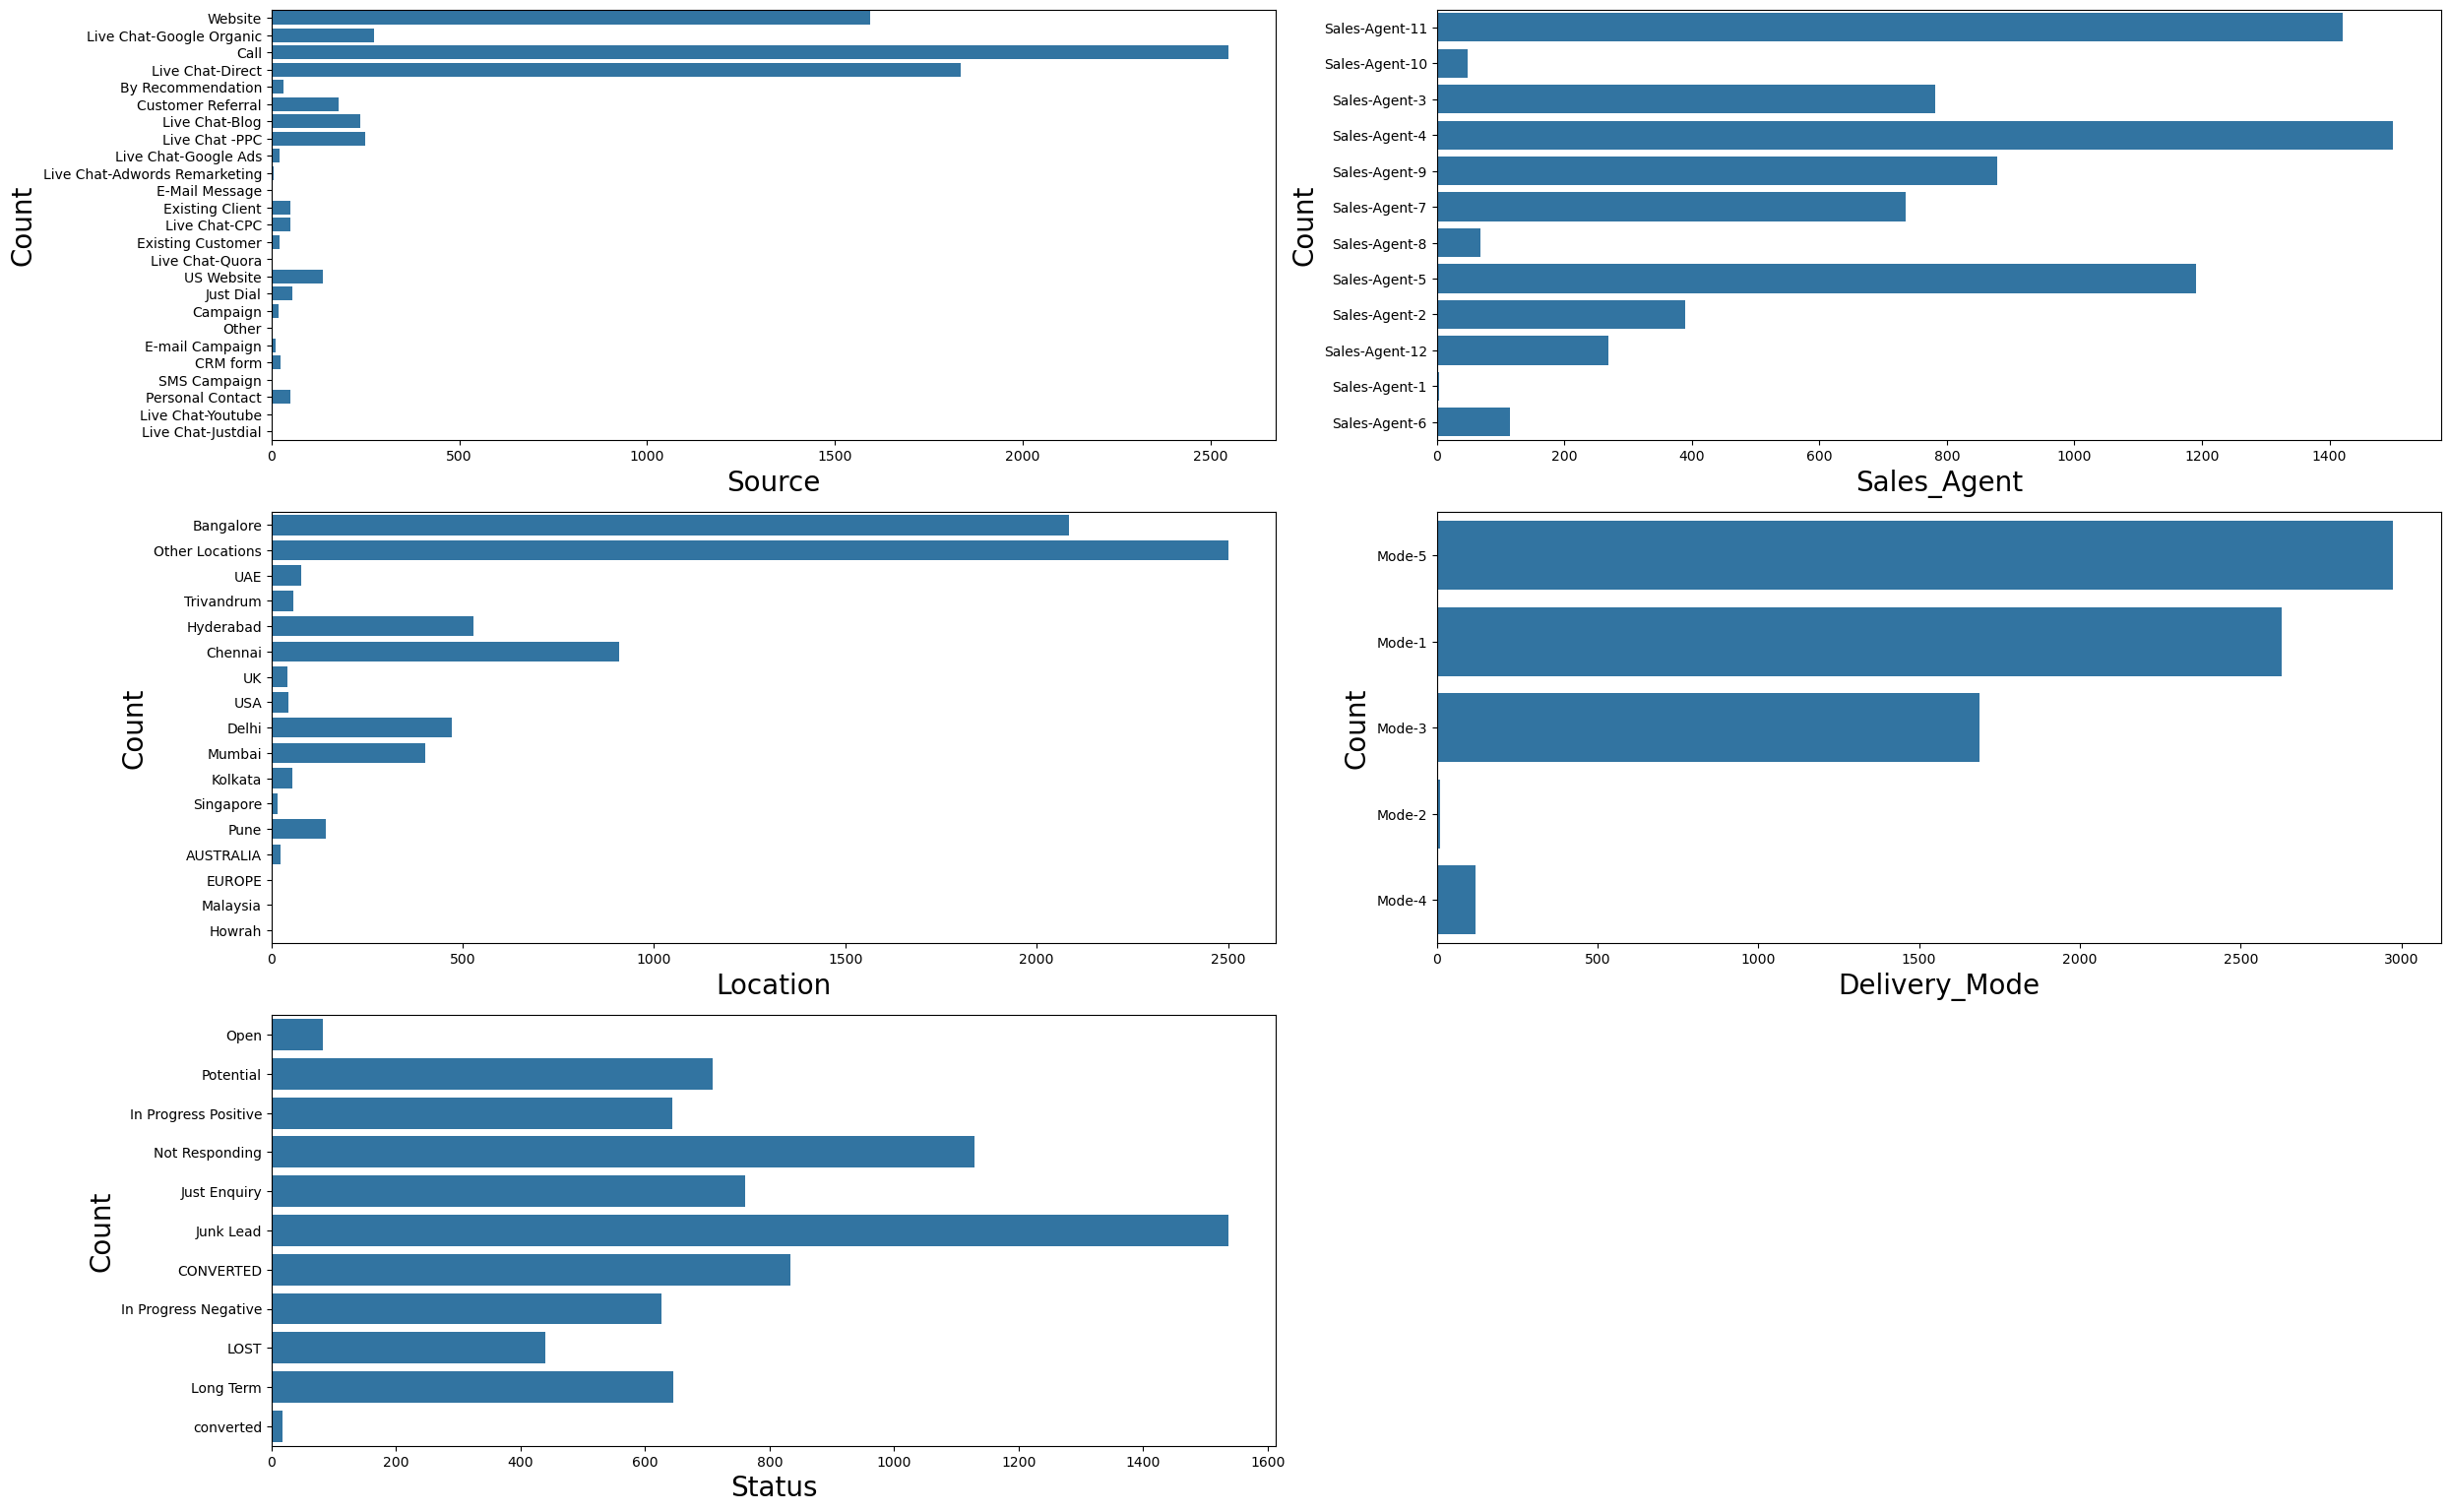

In [10]:
cat_cols =['Source','Sales_Agent',
       'Location', 'Delivery_Mode', 'Status']

plt.figure(figsize=(25,20))
pltnum=1
for col in cat_cols:
    plt.subplot(4,2,pltnum)
    sns.countplot(y=df[col])
    plt.xlabel(col,fontsize=20)
    plt.ylabel('Count',fontsize=20)
    pltnum+=1
plt.tight_layout()
plt.show()

Top Performers
Source: One dominant source (likely "Online" or similar, rightmost bar) accounts for over 200 counts, far exceeding others; bottom sources are negligible (<20).

Location: A single location (bottom bar) leads with ~250, followed by two mid-tier ones (~150-200); most trail below 100.

Sales Agent: Leading agent hits ~250, with a strong second (~220), then a drop-off; tail agents under 50.

Delivery Patterns
Delivery Mode shows even more concentration: top mode ~280, second ~220, third ~160, with the last minimal (~20). This suggests heavy reliance on 1-2 primary modes, potentially standard vs. express.

# Bivariante

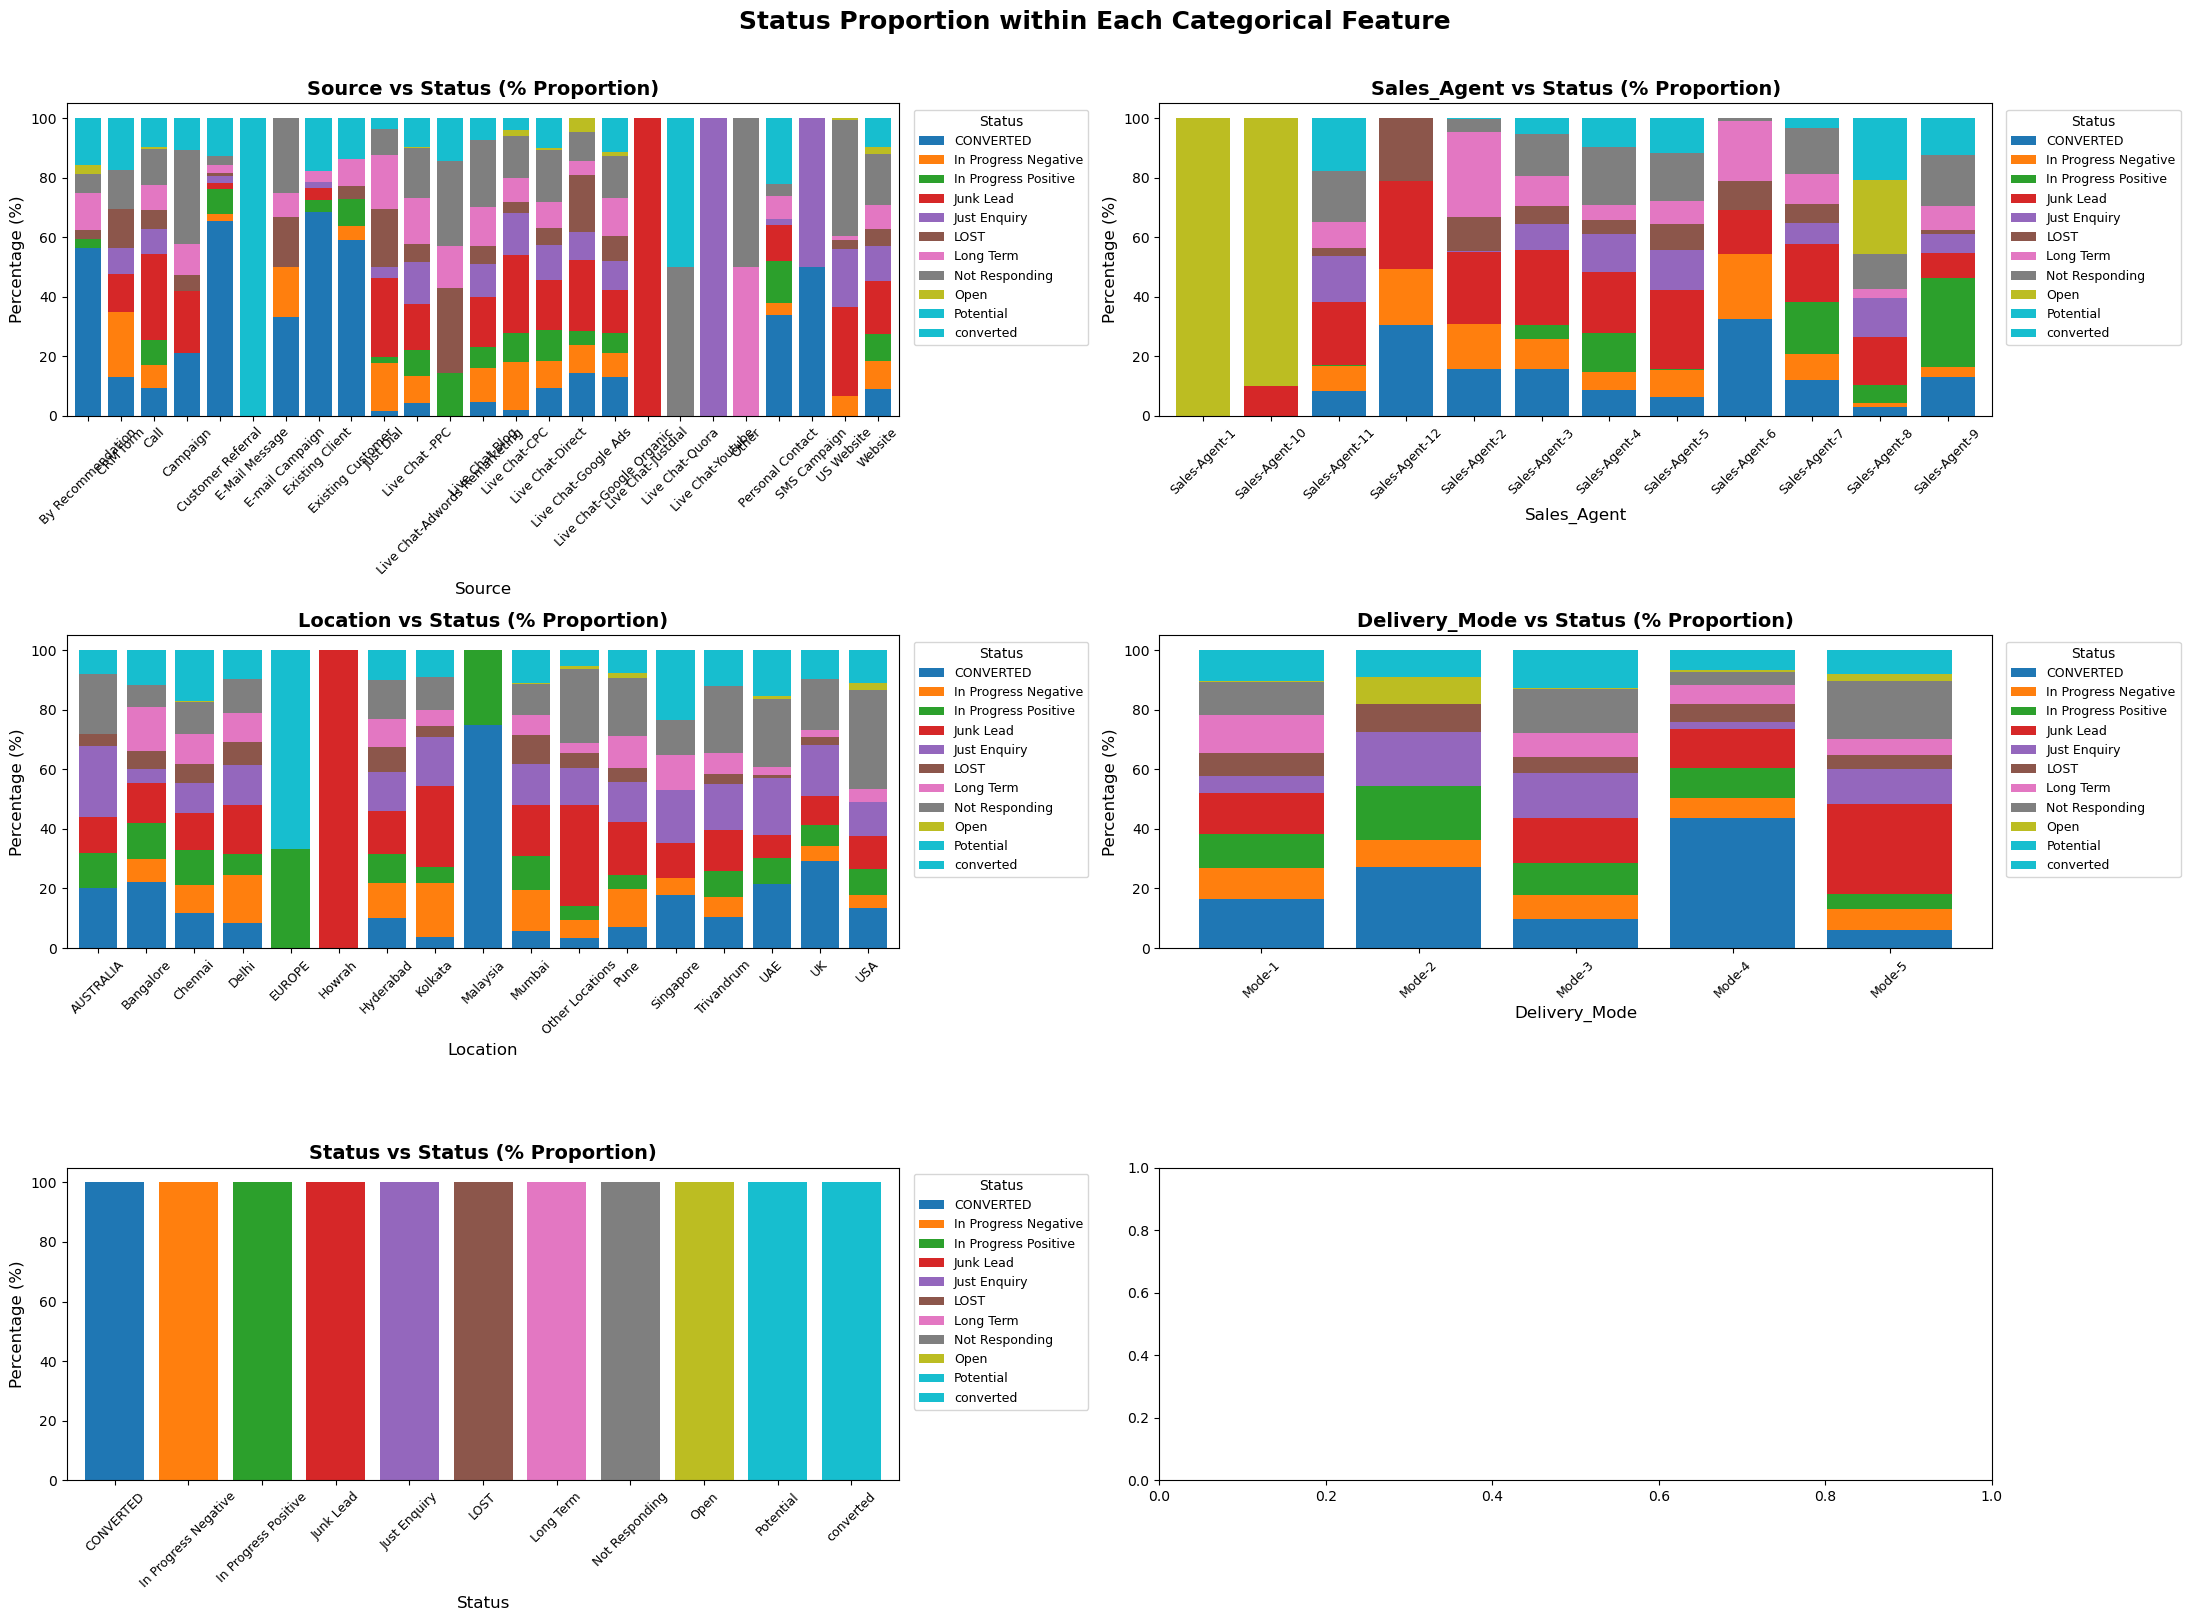

✅ Saved: bivariate_stacked_bar.png


In [11]:
fig, axes = plt.subplots(3, 2, figsize=(22, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    prop_df = (df.groupby([col, 'Status'])
                 .size()
                 .unstack(fill_value=0))
    prop_df = prop_df.div(prop_df.sum(axis=1), axis=0) * 100  # convert to %
    prop_df.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.8)
    ax.set_title(f'{col} vs Status (% Proportion)', fontsize=14, fontweight='bold')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.legend(title='Status', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=9)

plt.suptitle('Status Proportion within Each Categorical Feature', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bivariate_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: bivariate_stacked_bar.png")


1. Source vs Status Insights:-
High Conversion Sources:-
.Email Campaigns and Existing Customers show a higher proportion of CONVERTED leads.
.Live Chat – Direct and Google Ads also produce a reasonable conversion rate.

Low Quality Lead Sources:-
.Campaigns and Customer Referral sources contain higher proportions of:
 .Just Enquiry
 .Not Responding
 .Potential

2. Sales Agent vs Status Insights:-
   
Best Performing Agents:-
Agents with higher Converted proportions:
.Sales Agent 12
.Sales Agent 6
.Sales Agent 7

Agents with High Open Leads:-
Some agents show large Open / Potential segments, indicating:
.Leads still in pipeline
.Slower closing rate

3. Location vs Status Insights-

Strong Conversion Locations:
Locations showing higher Converted proportions:
.Bangalore
.Hyderabad
.Mumbai

These cities likely have higher product demand or better customer targeting.
Locations with Many Potential Leads

Some locations have higher:
.Potential
.Open

This indicates untapped market opportunities.

Locations with High Junk Leads:
Certain locations show higher Junk Lead proportions, meaning:
Poor targeting in those regions.


4. Delivery Mode vs Status Insights:-

Highest Conversion:
Mode 4 has the largest proportion of converted leads.
Balanced Modes

Mode 1 and Mode 2 show balanced distribution between:
.Converted
.Potential
.In Progress

Low Performance Mode:
.Mode 5 has a higher proportion of:
.Junk Lead
.Lost

5. Overall Funnel Insight:-

Across all charts, the lead statuses follow a typical sales funnel pattern:
Lead Stages:
.Open
.Potential
.In Progress
.Converted

Leakage Points:
.Junk Lead
.Not Responding
.Lost

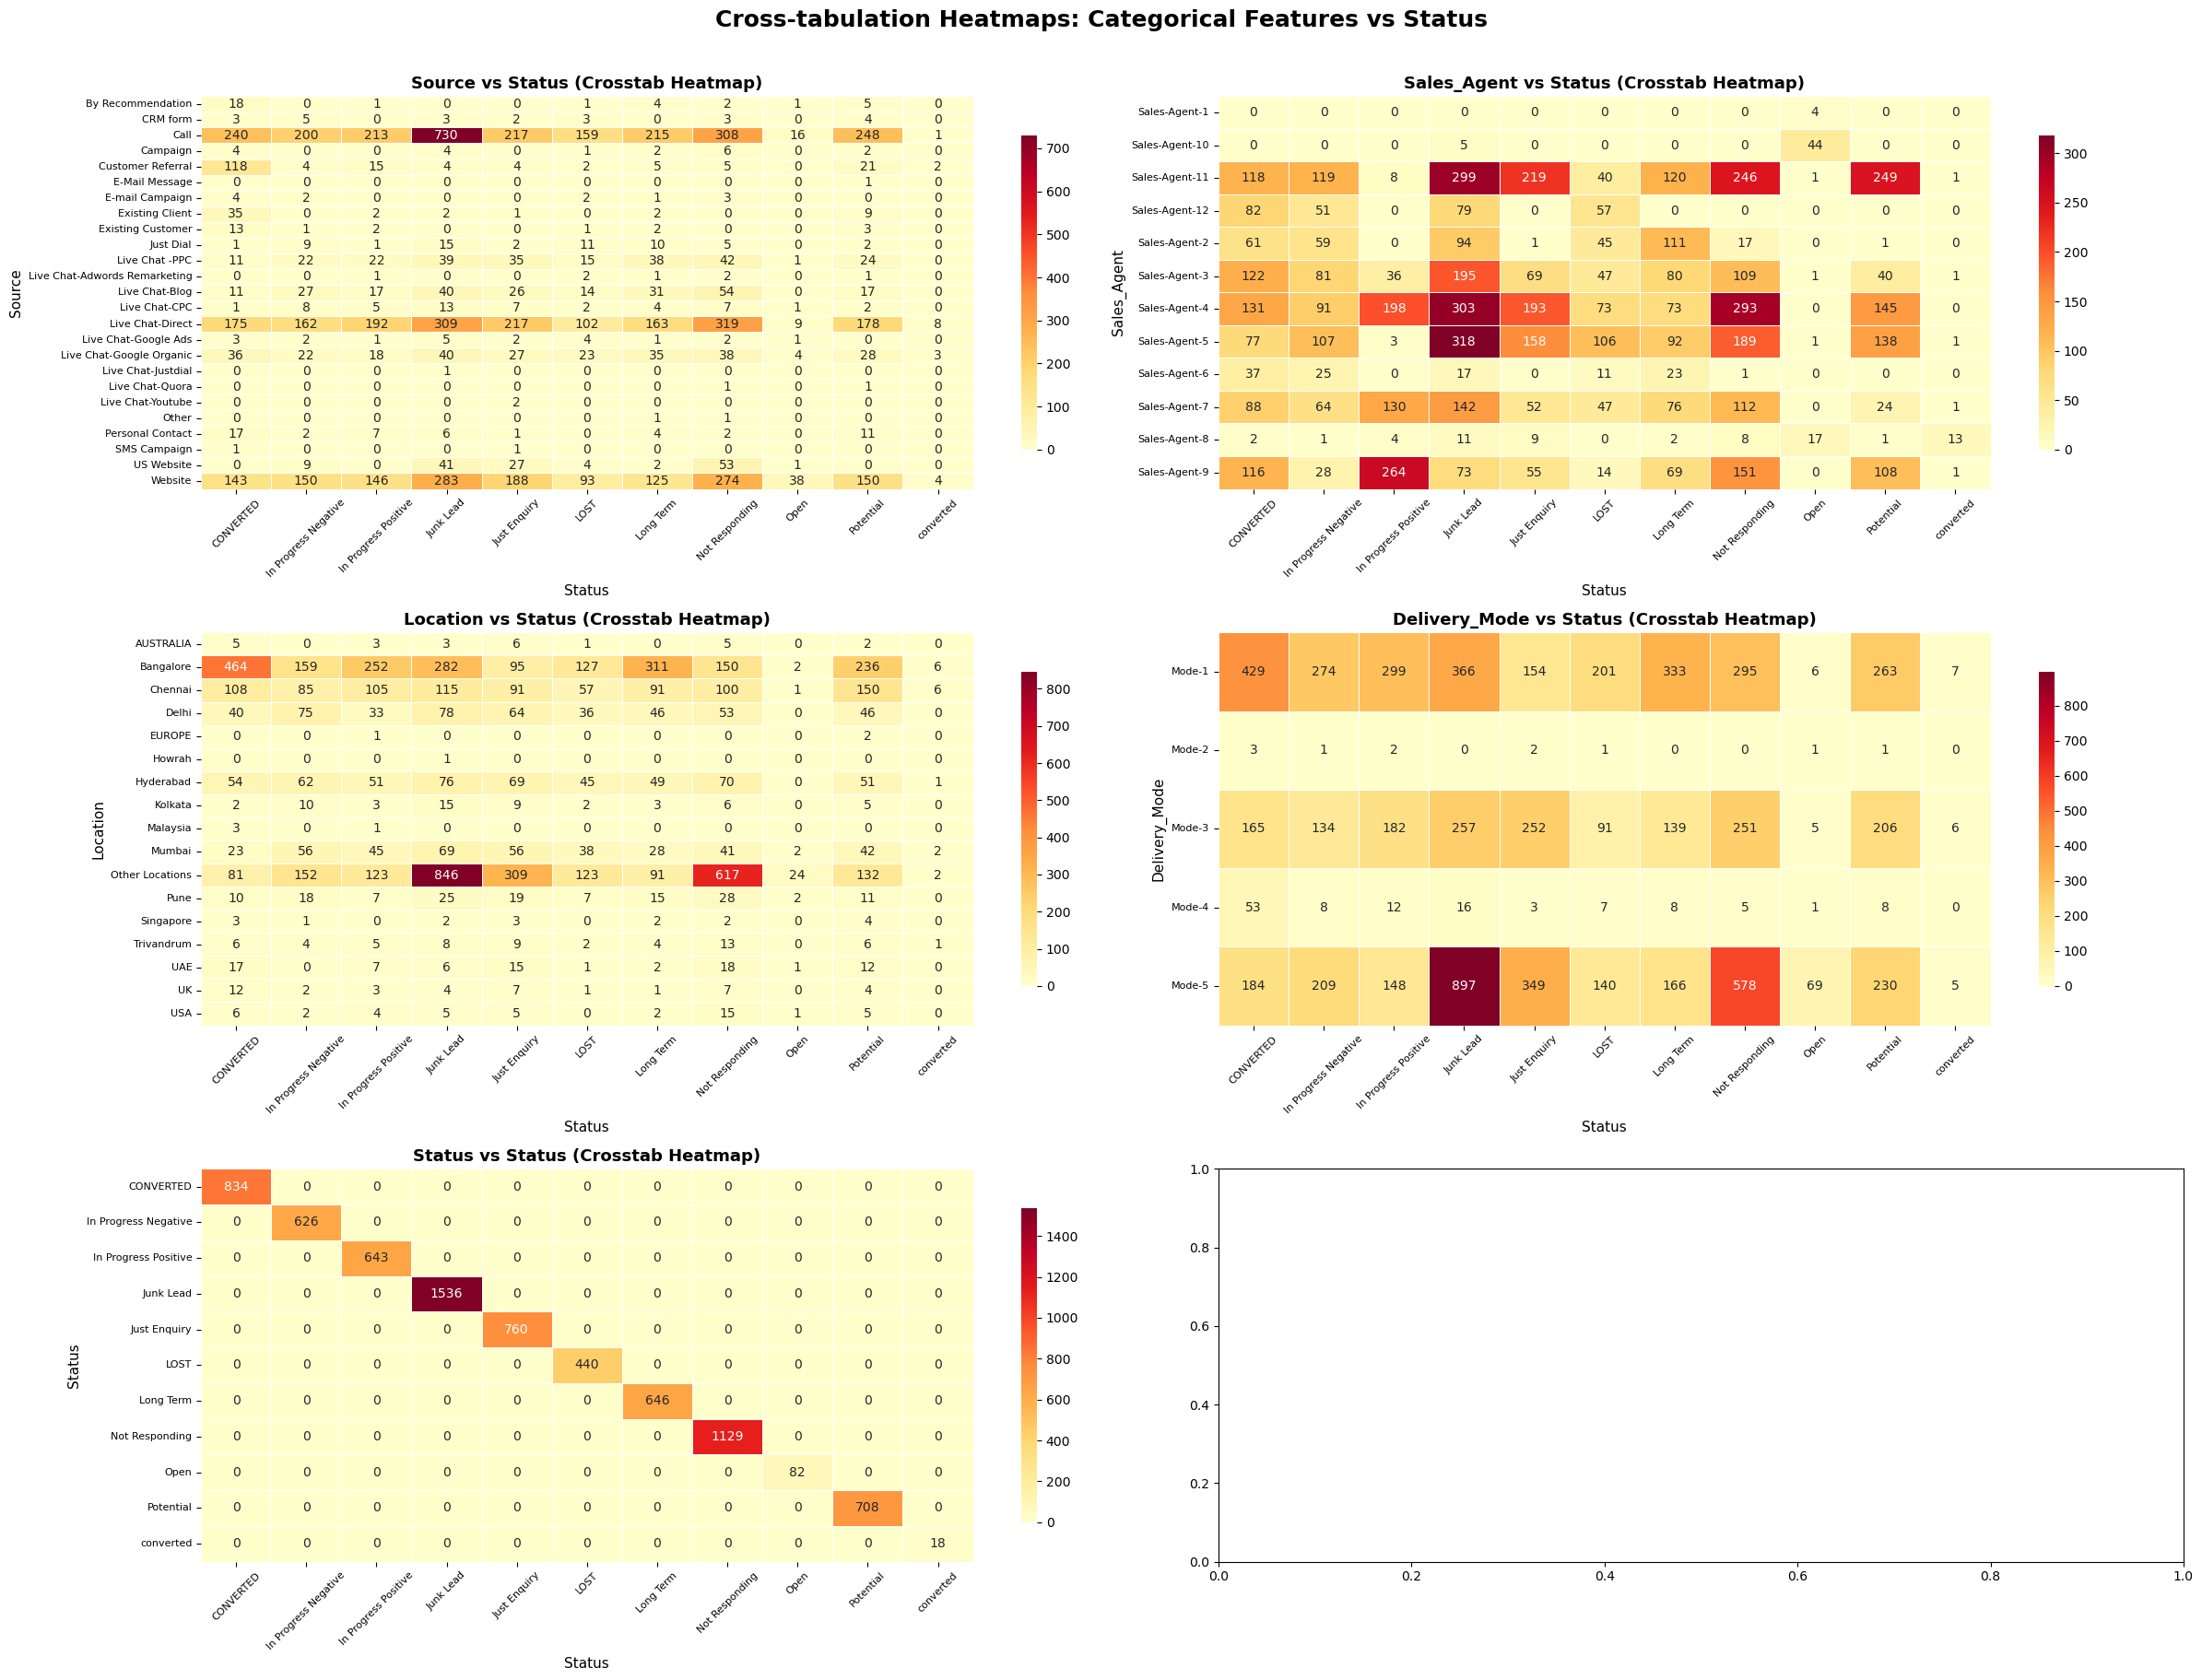

✅ Saved: bivariate_heatmaps.png


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(24, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['Status'])
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{col} vs Status (Crosstab Heatmap)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Status', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Cross-tabulation Heatmaps: Categorical Features vs Status', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bivariate_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: bivariate_heatmaps.png")


# Lead Source analyze

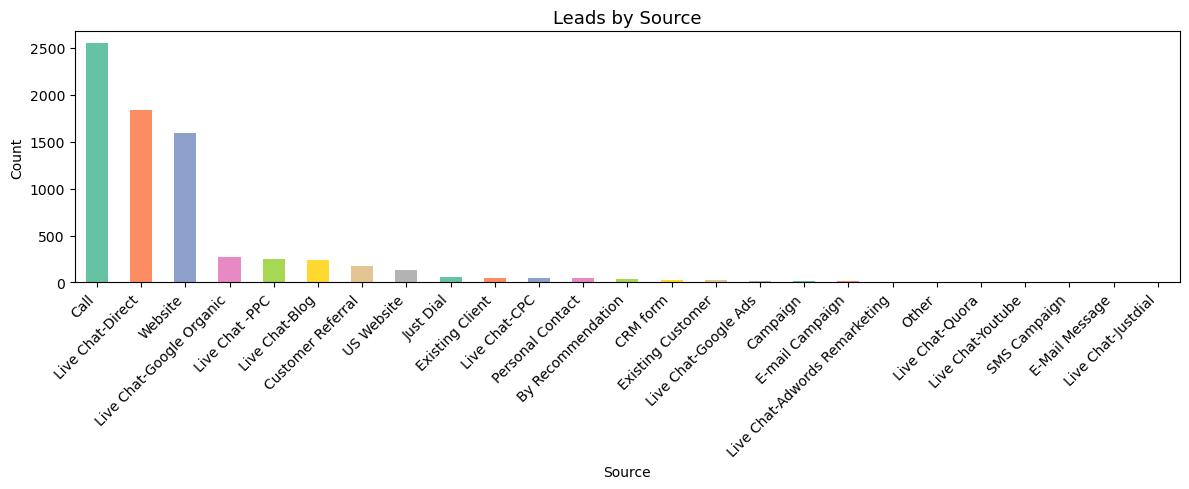

In [13]:
source_counts = df['Source'].value_counts()

plt.figure(figsize=(12, 5))
source_counts.plot(kind='bar', color=sns.color_palette('Set2', len(source_counts)))
plt.title('Leads by Source', fontsize=13)
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

1.Top Lead Sources (Major Contributors):-
The majority of leads come from a few dominant channels:
.Call → ~2550 leads (Highest)
.Live Chat – Direct → ~1850 leads
.Website → ~1600 leads

2.Mid-Level Lead Sources:-
These sources generate a moderate number of leads:
.Live Chat – Google Organic → ~270
.Live Chat – PPC → ~250
.Live Chat – Blog → ~230
.Customer Referral → ~200
.US Website → ~150

3.Low Performing Channels:-
Several channels produce very few leads:
.Just Dial
.Existing Client
.Live Chat – CPC
.Personal Contact
.Recommendation
.CRM Form
.Existing Customer

4.Very Low / Negligible Sources:-
Almost no leads come from:
.Google Ads
.Email Campaign
.SMS Campaign
.Live Chat – YouTube
.Live Chat – Quora
.Email Message

# Conversion Rate by Source

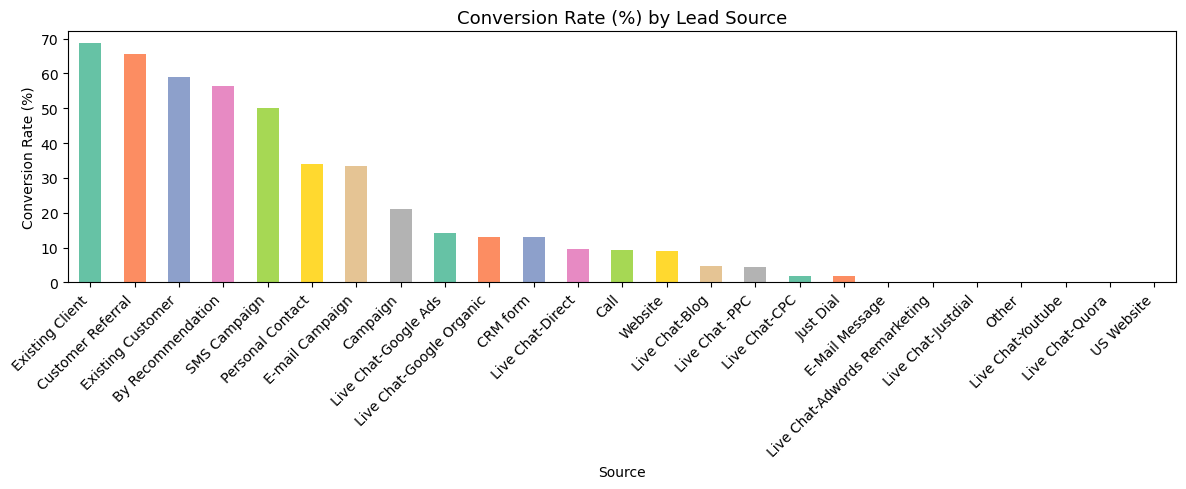

                               sum  count  conv_rate
Source                                              
Existing Client                 35     51      68.63
Customer Referral              118    180      65.56
Existing Customer               13     22      59.09
By Recommendation               18     32      56.25
SMS Campaign                     1      2      50.00
Personal Contact                17     50      34.00
E-mail Campaign                  4     12      33.33
Campaign                         4     19      21.05
Live Chat-Google Ads             3     21      14.29
Live Chat-Google Organic        36    274      13.14
CRM form                         3     23      13.04
Live Chat-Direct               175   1834       9.54
Call                           240   2547       9.42
Website                        143   1594       8.97
Live Chat-Blog                  11    237       4.64
Live Chat -PPC                  11    249       4.42
Live Chat-CPC                    1     50     

In [14]:
df['is_converted'] = (df['Status'] == 'CONVERTED').astype(int)

conv_by_source = df.groupby('Source')['is_converted'].agg(['sum', 'count'])
conv_by_source['conv_rate'] = (conv_by_source['sum'] / conv_by_source['count'] * 100).round(2)
conv_by_source = conv_by_source.sort_values('conv_rate', ascending=False)

plt.figure(figsize=(12, 5))
conv_by_source['conv_rate'].plot(kind='bar', color=sns.color_palette('Set2', len(conv_by_source)))
plt.title('Conversion Rate (%) by Lead Source', fontsize=13)
plt.xlabel('Source')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(conv_by_source)

# Location Analysis

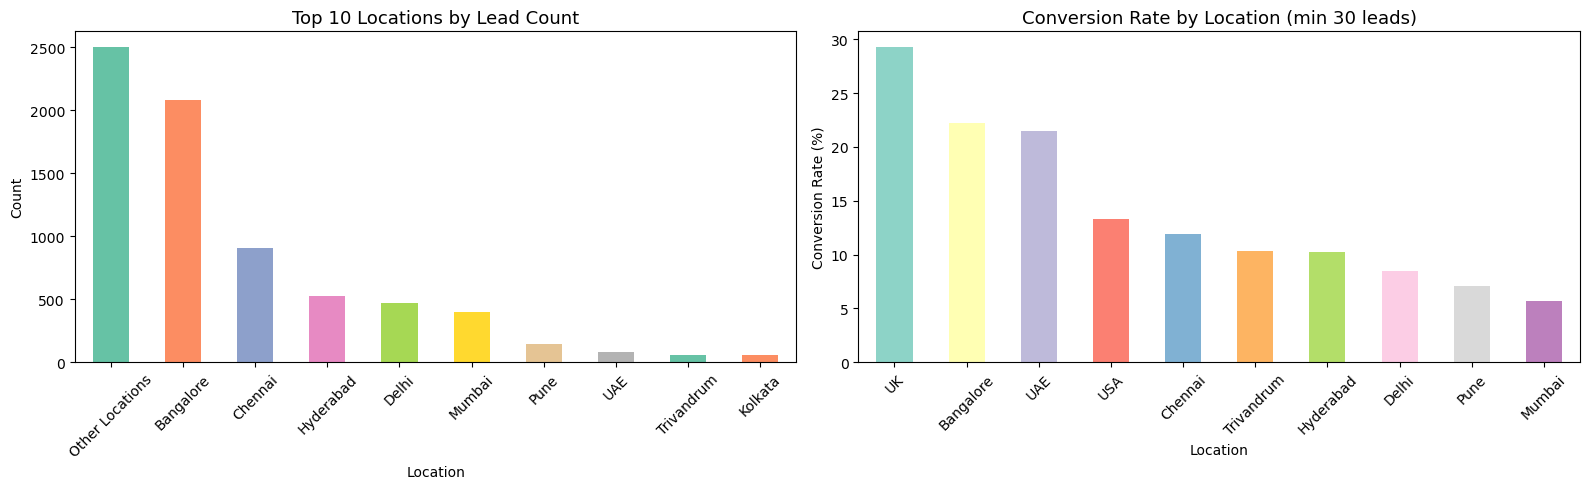

In [15]:
top_locations = df['Location'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_locations.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', 10))
axes[0].set_title('Top 10 Locations by Lead Count', fontsize=13)
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Conversion by Location
conv_by_loc = df.groupby('Location')['is_converted'].agg(['sum', 'count'])
conv_by_loc['conv_rate'] = (conv_by_loc['sum'] / conv_by_loc['count'] * 100).round(2)
conv_by_loc = conv_by_loc[conv_by_loc['count'] >= 30].sort_values('conv_rate', ascending=False).head(10)

conv_by_loc['conv_rate'].plot(kind='bar', ax=axes[1], color=sns.color_palette('Set3', 10))
axes[1].set_title('Conversion Rate by Location (min 30 leads)', fontsize=13)
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

1.Lead Generation by Location:-
The largest number of leads come from:
.Other Locations → ~2500 leads
.Bangalore → ~2100 leads
.Chennai → ~900 leads
.Hyderabad → ~520 leads
.Delhi → ~470 leads

2.Conversion Rate by Location:-
Locations with the highest conversion rate:
.UK → ~29%
.Bangalore → ~22%
.UAE → ~21%
.USA → ~13%
.Chennai → ~12%

Lowest conversion:
.Mumbai → ~6%
.Pune → ~7%

# Sales Agent Performance

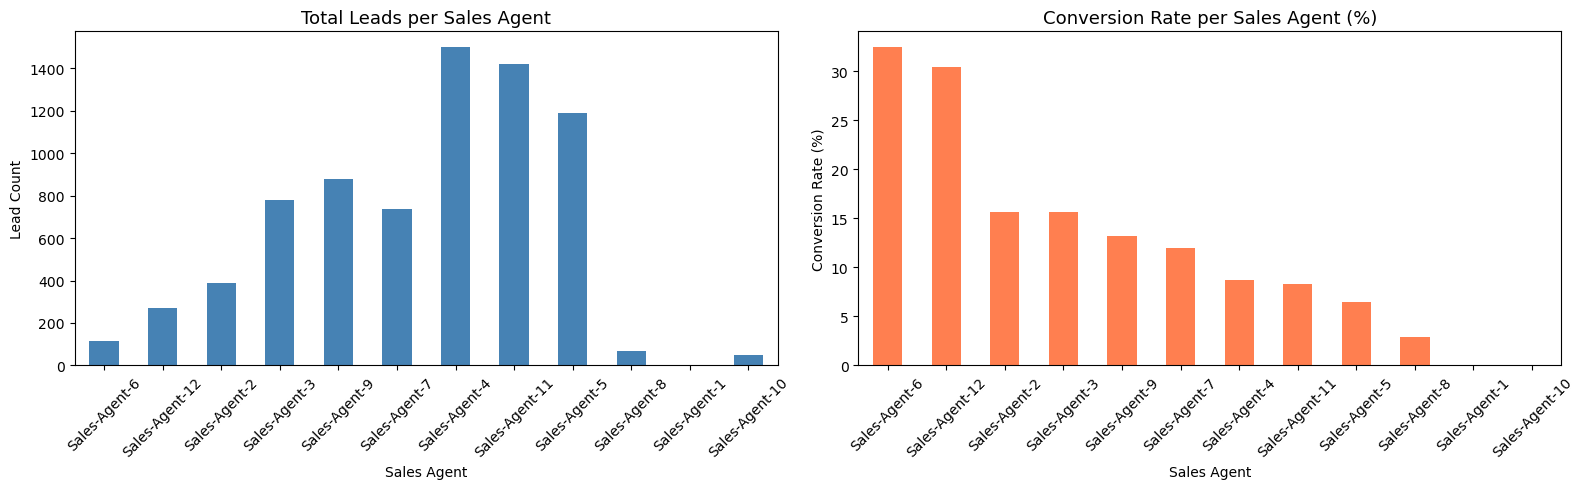

                sum  count  conv_rate
Sales_Agent                          
Sales-Agent-6    37    114      32.46
Sales-Agent-12   82    269      30.48
Sales-Agent-2    61    389      15.68
Sales-Agent-3   122    781      15.62
Sales-Agent-9   116    879      13.20
Sales-Agent-7    88    736      11.96
Sales-Agent-4   131   1500       8.73
Sales-Agent-11  118   1420       8.31
Sales-Agent-5    77   1190       6.47
Sales-Agent-8     2     68       2.94
Sales-Agent-1     0      4       0.00
Sales-Agent-10    0     49       0.00


In [16]:
agent_perf = df.groupby('Sales_Agent')['is_converted'].agg(['sum', 'count'])
agent_perf['conv_rate'] = (agent_perf['sum'] / agent_perf['count'] * 100).round(2)
agent_perf = agent_perf.sort_values('conv_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

agent_perf['count'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Leads per Sales Agent', fontsize=13)
axes[0].set_xlabel('Sales Agent')
axes[0].set_ylabel('Lead Count')
axes[0].tick_params(axis='x', rotation=45)

agent_perf['conv_rate'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Conversion Rate per Sales Agent (%)', fontsize=13)
axes[1].set_xlabel('Sales Agent')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print(agent_perf)

# Delivery Mode Analysis

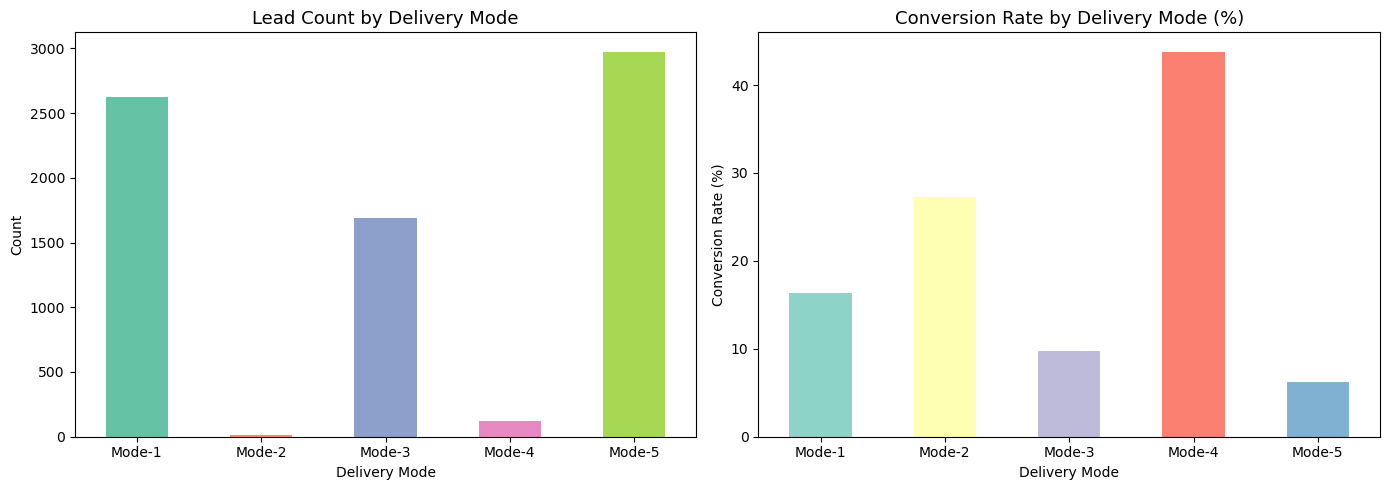

               sum  count  conv_rate
Delivery_Mode                       
Mode-1         429   2627      16.33
Mode-2           3     11      27.27
Mode-3         165   1688       9.77
Mode-4          53    121      43.80
Mode-5         184   2975       6.18


In [17]:
conv_by_mode = df.groupby('Delivery_Mode')['is_converted'].agg(['sum', 'count'])
conv_by_mode['conv_rate'] = (conv_by_mode['sum'] / conv_by_mode['count'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conv_by_mode['count'].plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', 5))
axes[0].set_title('Lead Count by Delivery Mode', fontsize=13)
axes[0].set_xlabel('Delivery Mode')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

conv_by_mode['conv_rate'].plot(kind='bar', ax=axes[1], color=sns.color_palette('Set3', 5))
axes[1].set_title('Conversion Rate by Delivery Mode (%)', fontsize=13)
axes[1].set_xlabel('Delivery Mode')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(conv_by_mode)

# Time-Based Analysis

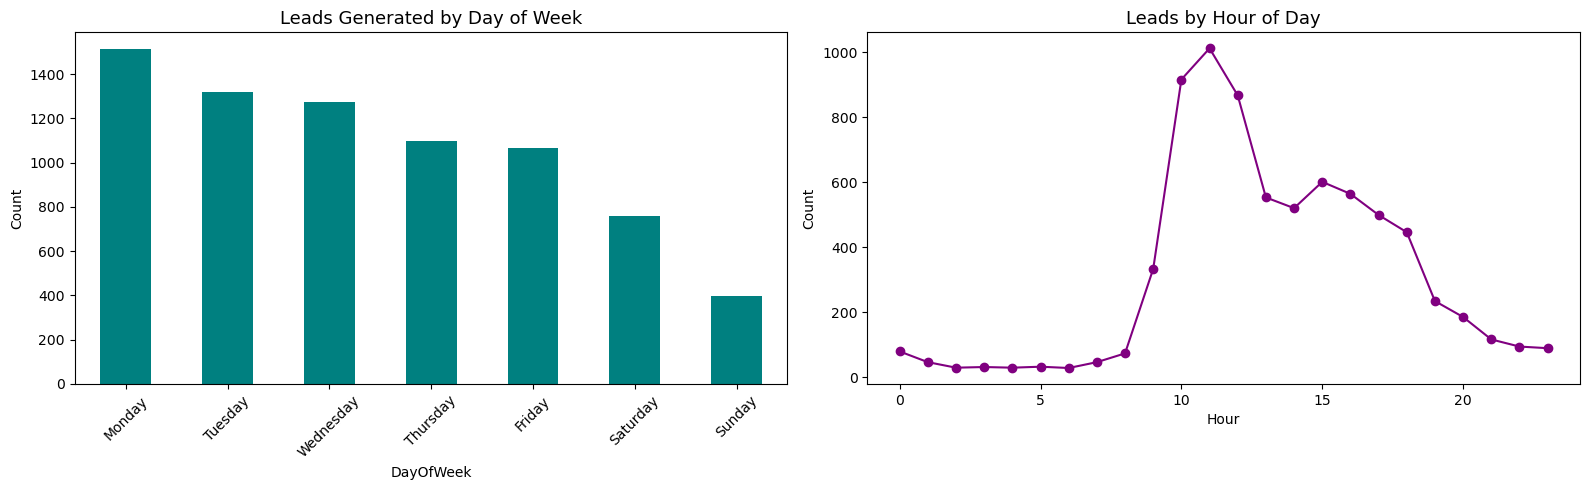

In [18]:
df['Created_dt'] = pd.to_datetime(df['Created'], dayfirst=True, errors='coerce')
df['Month'] = df['Created_dt'].dt.month
df['DayOfWeek'] = df['Created_dt'].dt.day_name()
df['Hour'] = df['Created_dt'].dt.hour

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

leads_by_day = df.groupby('DayOfWeek').size().reindex(day_order)
leads_by_day.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Leads Generated by Day of Week', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df.groupby('Hour').size().plot(kind='line', ax=axes[1], marker='o', color='purple')
axes[1].set_title('Leads by Hour of Day', fontsize=13)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

1.Leads by Day of Week:-
. Monday (~1500 leads) generates the highest number of leads.

. Tuesday (~1320) and Wednesday (~1270) also perform strongly.

. Thursday (~1100) and Friday (~1070) show a moderate decline.

. Saturday (~750) drops significantly.

. Sunday (~400) has the lowest lead generation.

2.Leads by Hour of Day:-
. Midnight–7 AM: Very low activity (30–80 leads).

. 9 AM: Leads start rising quickly.

. 10 AM (~900 leads) and 11 AM (~1000 leads) are peak hours.

. 12 PM (~870) remains strong.

. 1–4 PM (~520–600) still maintains good engagement.

. After 6 PM: Leads decline steadily.

. 9–11 PM: Very low activity again.

#  Mobile/Email Quality Check

Valid mobile numbers : 1 (0.0%)
Valid email addresses: 4841 (65.2%)


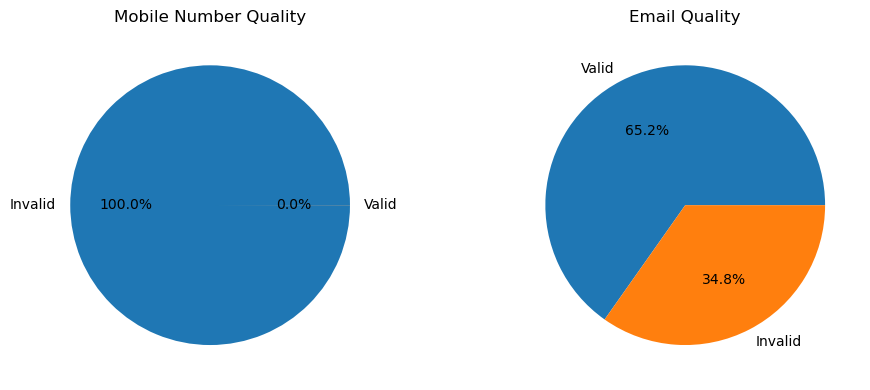

In [19]:
# Check valid mobile (10-digit numbers)
df['mobile_clean'] = df['Mobile'].str.replace(r'\D', '', regex=True)
df['valid_mobile'] = df['mobile_clean'].apply(lambda x: 1 if pd.notna(x) and len(str(x)) == 10 else 0)

# Check valid email
df['valid_email'] = df['EMAIL'].str.contains(r'^[\w\.-]+@[\w\.-]+\.\w+$', na=False, regex=True).astype(int)

print(f"Valid mobile numbers : {df['valid_mobile'].sum()} ({df['valid_mobile'].mean()*100:.1f}%)")
print(f"Valid email addresses: {df['valid_email'].sum()} ({df['valid_email'].mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['valid_mobile'].value_counts().rename({0:'Invalid', 1:'Valid'}).plot(kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Mobile Number Quality')
axes[0].set_ylabel('')

df['valid_email'].value_counts().rename({0:'Invalid', 1:'Valid'}).plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Email Quality')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

1.Mobile Number Quality:-

Observation:

❌ Invalid Mobile Numbers: 100%

✅ Valid Mobile Numbers: 0%

2.Email Quality:-

Observation:

✅ Valid Emails: 65.2%

❌ Invalid Emails: 34.8%

# Data_Preprocessing

In [20]:
df.isnull().sum()

Created             0
Product_ID         58
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
is_converted        0
Created_dt          0
Month               0
DayOfWeek           0
Hour                0
mobile_clean     1810
valid_mobile        0
valid_email         0
dtype: int64

In [21]:
df.isna().sum()

Created             0
Product_ID         58
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
is_converted        0
Created_dt          0
Month               0
DayOfWeek           0
Hour                0
mobile_clean     1810
valid_mobile        0
valid_email         0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(2)

In [23]:
#Droping duplicate values
df = df.drop_duplicates()

In [24]:
df.duplicated().sum()

np.int64(0)

Lead Category Distribution:
Lead_Category
Low Potential     6586
High Potential     834
Name: count, dtype: int64


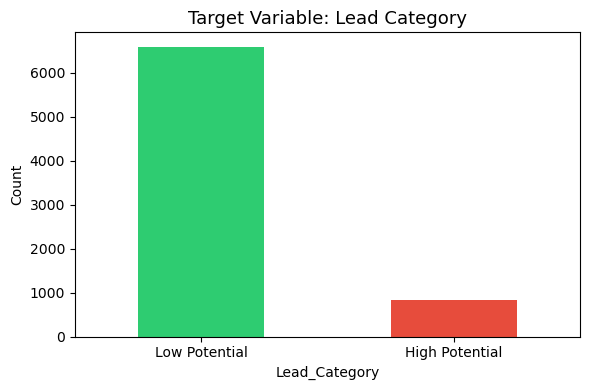

In [25]:
# Define High Potential vs Low Potential
high_potential_statuses = ['CONVERTED', 'POTENTIAL', 'IN PROGRESS POSITIVE']
df['Lead_Category'] = df['Status'].apply(
    lambda x: 'High Potential' if x in high_potential_statuses else 'Low Potential'
)

print('Lead Category Distribution:')
print(df['Lead_Category'].value_counts())

plt.figure(figsize=(6, 4))
df['Lead_Category'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Target Variable: Lead Category', fontsize=13)
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [27]:
# Encode features
df_ml = df[['Source', 'Location', 'Delivery_Mode', 'Sales_Agent',
            'valid_mobile', 'valid_email', 'Hour', 'DayOfWeek', 'Lead_Category']].copy()

df_ml.dropna(inplace=True)

le = LabelEncoder()
cat_cols = ['Source', 'Location', 'Delivery_Mode', 'Sales_Agent', 'DayOfWeek']
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

df_ml['Lead_Category_enc'] = (df_ml['Lead_Category'] == 'High Potential').astype(int)

print(f'ML dataset shape: {df_ml.shape}')
df_ml.head()

ML dataset shape: (7334, 10)


,Source,Location,Delivery_Mode,Sales_Agent,valid_mobile,valid_email,Hour,DayOfWeek,Lead_Category,Lead_Category_enc
18,16,1,0,4,0,1,18,5,Low Potential,0
19,2,10,4,5,0,0,18,5,Low Potential,0
23,2,14,2,10,0,1,17,5,Low Potential,0
24,24,13,0,1,0,1,17,5,Low Potential,0
25,24,6,0,8,0,1,16,5,Low Potential,0


# Model Building

In [49]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,f1_score,precision_score,recall_score,
                             accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [40]:
X = df_ml[['Source', 'Location', 'Delivery_Mode', 'Sales_Agent',
           'valid_mobile', 'valid_email', 'Hour', 'DayOfWeek']]
y = df_ml['Lead_Category_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Class balance (train): {pd.Series(y_train).value_counts().to_dict()}')

Train size: 5867 | Test size: 1467
Class balance (train): {0: 5200, 1: 667}


In [41]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'Naive Bayes':         GaussianNB()
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy').mean()
    results[name] = {'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4), 'CV Accuracy': round(cv, 4)}
    print(f'{name:25s}  Accuracy: {acc:.4f}  ROC-AUC: {auc:.4f}  CV: {cv:.4f}')

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print('\n=== Model Comparison ===')
print(results_df)

Logistic Regression        Accuracy: 0.8862  ROC-AUC: 0.7515  CV: 0.8861
Decision Tree              Accuracy: 0.8248  ROC-AUC: 0.5886  CV: 0.8265
Random Forest              Accuracy: 0.8821  ROC-AUC: 0.7467  CV: 0.8841
Gradient Boosting          Accuracy: 0.9005  ROC-AUC: 0.8178  CV: 0.8948
SVM                        Accuracy: 0.8862  ROC-AUC: 0.6873  CV: 0.8863
Naive Bayes                Accuracy: 0.1138  ROC-AUC: 0.7228  CV: 0.2680

=== Model Comparison ===
                     Accuracy  ROC-AUC  CV Accuracy
Gradient Boosting      0.9005   0.8178       0.8948
Logistic Regression    0.8862   0.7515       0.8861
Random Forest          0.8821   0.7467       0.8841
Naive Bayes            0.1138   0.7228       0.2680
SVM                    0.8862   0.6873       0.8863
Decision Tree          0.8248   0.5886       0.8265


In [42]:
best_model = models['Gradient Boosting']
y_pred_best = best_model.predict(X_test_sc)
y_prob_best = best_model.predict_proba(X_test_sc)[:, 1]

print('Classification Report – Gradient Boosting')
print(classification_report(y_test, y_pred_best,
                             target_names=['Low Potential', 'High Potential']))

Classification Report – Gradient Boosting
                precision    recall  f1-score   support

 Low Potential       0.91      0.99      0.95      1300
High Potential       0.73      0.20      0.31       167

      accuracy                           0.90      1467
     macro avg       0.82      0.59      0.63      1467
  weighted avg       0.89      0.90      0.87      1467



# Confusion Matrix

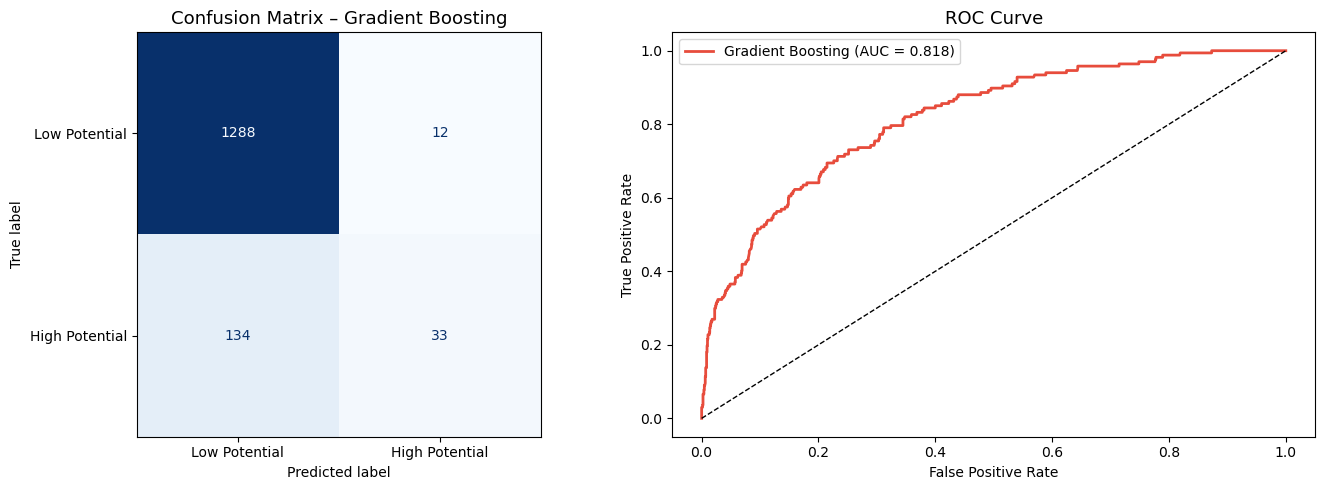

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low Potential', 'High Potential'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix – Gradient Boosting', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_score = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc_score:.3f})', color='#e74c3c', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature Importance

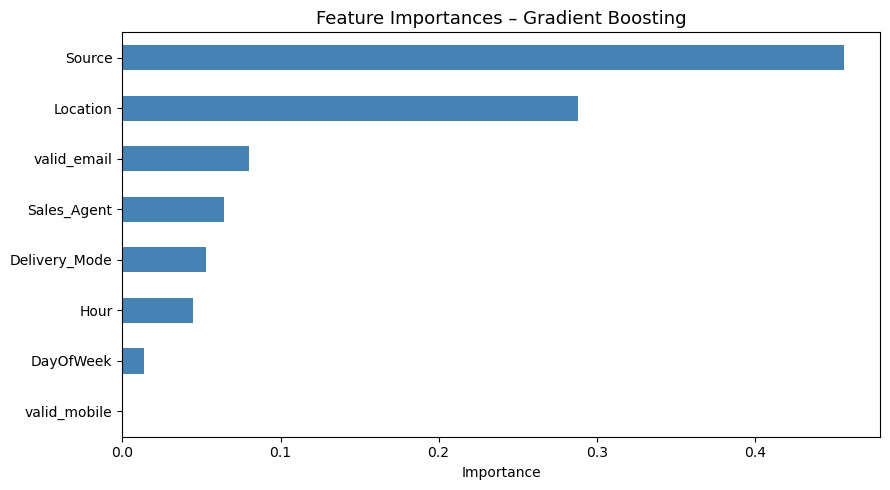

In [44]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importances – Gradient Boosting', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Hyper-parameter Tuning

In [45]:
param_dist = {
    'n_estimators':       [100, 200, 300, 500],
    'learning_rate':      [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth':          [2, 3, 4, 5, 6],
    'subsample':          [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features':       ['sqrt', 'log2', None],
    'min_samples_split':  [2, 5, 10, 20],
    'min_samples_leaf':   [1, 2, 4, 8],
    'max_leaf_nodes':     [None, 10, 20, 31, 50],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_gb.fit(X_train_sc, y_train)

print(f"\nBest Params (RandomizedSearch):\n{random_search_gb.best_params_}")
print(f"Best CV ROC-AUC: {random_search_gb.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Params (RandomizedSearch):
{'subsample': 0.9, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': 'log2', 'max_depth': 2, 'learning_rate': 0.05}
Best CV ROC-AUC: 0.7903


In [46]:
best = random_search_gb.best_params_

def make_range(val, delta, min_val=1, as_float=False):
    """Helper to build a small grid around a best value."""
    if as_float:
        candidates = [round(val * 0.5, 4), val, round(val * 2, 4)]
    else:
        candidates = [max(min_val, val - delta), val, val + delta]
    return sorted(set(candidates))

param_grid_fine = {
    'n_estimators':      make_range(best['n_estimators'], 50, min_val=50),
    'learning_rate':     make_range(best['learning_rate'], 0, as_float=True),
    'max_depth':         make_range(best['max_depth'], 1, min_val=2),
    'subsample':         [best['subsample']],
    'max_features':      [best['max_features']],
    'min_samples_split': [best['min_samples_split']],
    'min_samples_leaf':  [best['min_samples_leaf']],
    'max_leaf_nodes':    [best['max_leaf_nodes']],
}

grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_fine,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search_gb.fit(X_train_sc, y_train)

print(f"\nBest Params (GridSearch fine-tune):\n{grid_search_gb.best_params_}")
print(f"Best CV ROC-AUC: {grid_search_gb.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Params (GridSearch fine-tune):
{'learning_rate': 0.025, 'max_depth': 3, 'max_features': 'log2', 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500, 'subsample': 0.9}
Best CV ROC-AUC: 0.7919


In [47]:
best_gb = grid_search_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test_sc)
y_prob_gb = best_gb.predict_proba(X_test_sc)[:, 1]

print("\n── Tuned Gradient Boosting Results ──")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Test ROC-AUC  : {roc_auc_score(y_test, y_prob_gb):.4f}")
print(classification_report(y_test, y_pred_gb,
                             target_names=['Low Potential', 'High Potential']))


── Tuned Gradient Boosting Results ──
Test Accuracy : 0.8984
Test ROC-AUC  : 0.8203
                precision    recall  f1-score   support

 Low Potential       0.91      0.99      0.95      1300
High Potential       0.67      0.22      0.33       167

      accuracy                           0.90      1467
     macro avg       0.79      0.60      0.64      1467
  weighted avg       0.88      0.90      0.87      1467



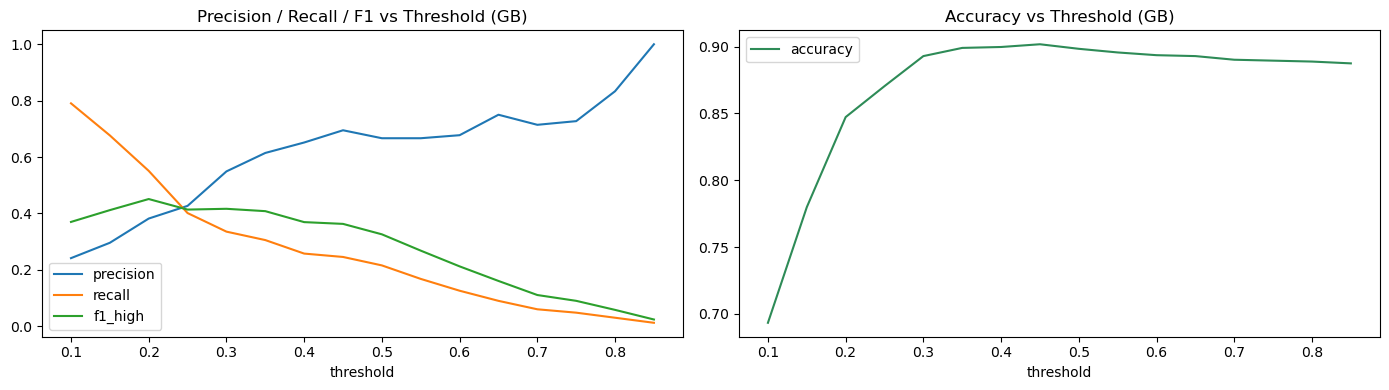


Optimal threshold (max F1 – High Potential): 0.20
                precision    recall  f1-score   support

 Low Potential       0.94      0.89      0.91      1300
High Potential       0.38      0.55      0.45       167

      accuracy                           0.85      1467
     macro avg       0.66      0.72      0.68      1467
  weighted avg       0.88      0.85      0.86      1467



In [50]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    preds = (y_prob_gb >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'accuracy':  accuracy_score(y_test, preds),
        'f1_high':   f1_score(y_test, preds, pos_label=1, zero_division=0),
        'precision': precision_score(y_test, preds, pos_label=1, zero_division=0),
        'recall':    recall_score(y_test, preds, pos_label=1, zero_division=0),
    })

thresh_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
thresh_df.plot(x='threshold', y=['precision', 'recall', 'f1_high'],
               ax=axes[0], title='Precision / Recall / F1 vs Threshold (GB)')
thresh_df.plot(x='threshold', y='accuracy', ax=axes[1],
               title='Accuracy vs Threshold (GB)', color='seagreen')
plt.tight_layout()
plt.show()

best_thresh_gb = thresh_df.loc[thresh_df['f1_high'].idxmax(), 'threshold']
print(f"\nOptimal threshold (max F1 – High Potential): {best_thresh_gb:.2f}")

y_pred_gb_thresh = (y_prob_gb >= best_thresh_gb).astype(int)
print(classification_report(y_test, y_pred_gb_thresh,
                             target_names=['Low Potential', 'High Potential']))